# Feature Engineering — Fraud_Data.csv

**Task 1 — Step 4**

This notebook documents all feature engineering applied to the e-commerce fraud dataset.

**Input:** `data/processed/fraud_geo.csv` (cleaned + country-enriched)  
**Output:** `data/processed/fraud_features.csv` (ready for transformation + modelling)

---

### Features Created

| Feature | Type | Description |
|---|---|---|
| `hour_of_day` | Time | Hour of purchase (0–23) |
| `day_of_week` | Time | Day of purchase (0=Mon, 6=Sun) |
| `time_since_signup` | Time | Seconds between signup and purchase |
| `transaction_count` | Velocity | Cumulative transactions per user |
| `transactions_last_24h` | Velocity | Transactions by same user in last 24 hours |

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Input Data

In [10]:
df = pd.read_csv('../data/processed/fraud_geo.csv')

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (151112, 12)
Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'country']


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46.0,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.496895,0,Unknown
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33.0,YFGYOALADBHLT,Ads,IE,F,30,93447.138961,0,Unknown
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33.0,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.501505,0,Unknown
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33.0,PIBUQMBIELMMG,Ads,IE,M,40,117566.664867,0,Unknown
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55.0,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.789042,0,Unknown


## 2. Parse Datetime Columns

Both `signup_time` and `purchase_time` are loaded as strings. We convert them to datetime so we can do arithmetic on them.

In [11]:
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['signup_time']   = pd.to_datetime(df['signup_time'])

print('purchase_time dtype:', df['purchase_time'].dtype)
print('signup_time dtype  :', df['signup_time'].dtype)
print()
print('purchase_time range:', df['purchase_time'].min(), '→', df['purchase_time'].max())
print('signup_time range  :', df['signup_time'].min(), '→', df['signup_time'].max())

purchase_time dtype: datetime64[us]
signup_time dtype  : datetime64[us]

purchase_time range: 2015-01-01 00:00:44 → 2015-12-16 02:56:05
signup_time range  : 2015-01-01 00:00:42 → 2015-08-18 04:40:29


## 3. Time Features

### 3.1 `hour_of_day`

**Why:** Fraud tends to happen at unusual hours (late night / early morning) when victims are unlikely to notice. Legitimate purchases cluster around business hours.

In [12]:
df['hour_of_day'] = df['purchase_time'].dt.hour

print('hour_of_day — value counts:')
print(df['hour_of_day'].describe())

hour_of_day — value counts:
count    151112.000000
mean         11.521593
std           6.912474
min           0.000000
25%           6.000000
50%          12.000000
75%          17.000000
max          23.000000
Name: hour_of_day, dtype: float64


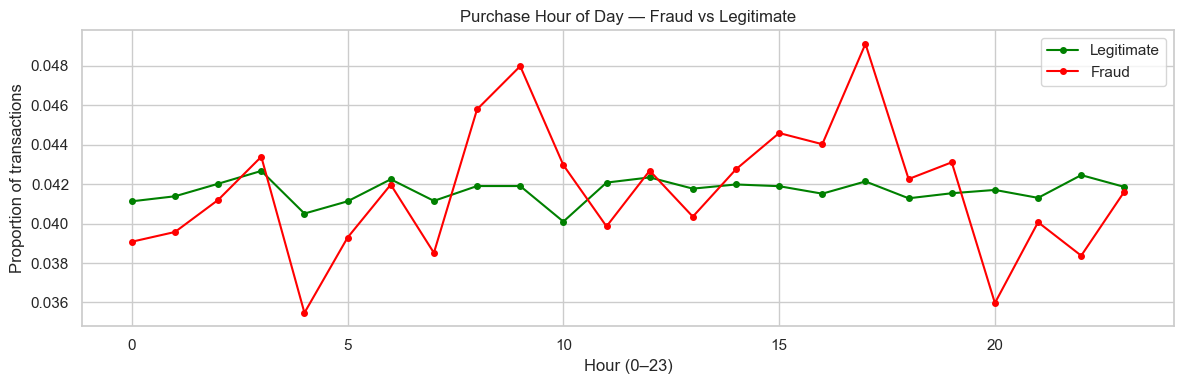

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

for label, colour, name in [(0, 'green', 'Legitimate'), (1, 'red', 'Fraud')]:
    counts = df[df['class'] == label]['hour_of_day'].value_counts().sort_index()
    ax.plot(counts.index, counts.values / counts.sum(),
            marker='o', markersize=4, label=name, color=colour)

ax.set_title('Purchase Hour of Day — Fraud vs Legitimate')
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Proportion of transactions')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_hour_of_day.png', dpi=150)
plt.show()

### 3.2 `day_of_week`

**Why:** Some fraud patterns concentrate on specific days (e.g. weekends when fraud teams are smaller).

0 = Monday … 6 = Sunday

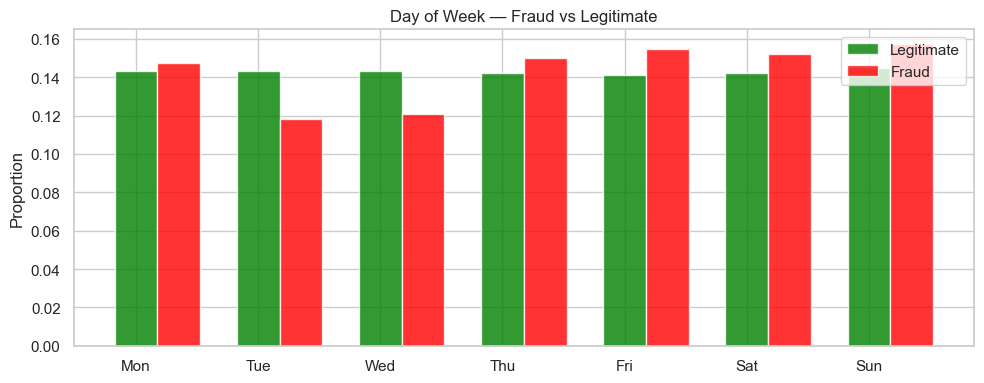

In [14]:
df['day_of_week'] = df['purchase_time'].dt.dayofweek

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 4))

for label, colour, name, offset in [(0, 'green', 'Legitimate', 0), (1, 'red', 'Fraud', 0.35)]:
    counts = df[df['class'] == label]['day_of_week'].value_counts().sort_index()
    ax.bar([d + offset for d in counts.index],
           counts.values / counts.sum(),
           width=0.35, color=colour, alpha=0.8, label=name)

ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_title('Day of Week — Fraud vs Legitimate')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_day_of_week.png', dpi=150)
plt.show()

### 3.3 `time_since_signup`

**Why:** Fraudsters typically create an account and make a purchase immediately using a stolen card. Legitimate users browse, compare, and buy over hours or days.

Stored in **seconds** so the model has full numeric precision.

In [16]:
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds()

print('time_since_signup stats (seconds):')
print(df['time_since_signup'].describe())
print()
print('In hours — median:', df['time_since_signup'].median() / 3600, 'h')
print('In days  — median:', df['time_since_signup'].median() / 86400, 'd')

time_since_signup stats (seconds):
count    1.511120e+05
mean     4.932029e+06
std      3.126263e+06
min      1.000000e+00
25%      2.186754e+06
50%      4.926346e+06
75%      7.644524e+06
max      1.036797e+07
Name: time_since_signup, dtype: float64

In hours — median: 1368.4293055555556 h
In days  — median: 57.01788773148148 d


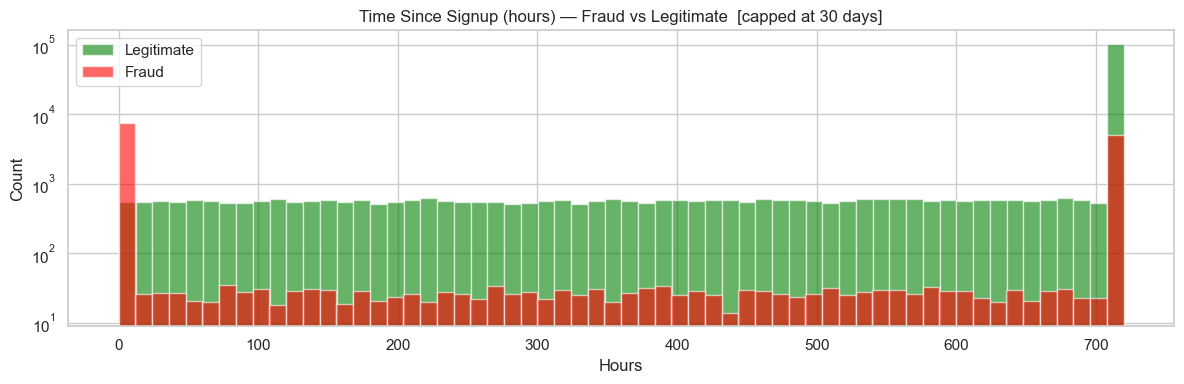

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

# Convert to hours for readability, cap at 30 days
cap_hours = 30 * 24

for label, colour, name in [(0, 'green', 'Legitimate'), (1, 'red', 'Fraud')]:
    vals = (df[df['class'] == label]['time_since_signup'] / 3600).clip(upper=cap_hours)
    ax.hist(vals, bins=60, alpha=0.6, color=colour, label=name)

ax.set_title('Time Since Signup (hours) — Fraud vs Legitimate  [capped at 30 days]')
ax.set_xlabel('Hours')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_time_since_signup.png', dpi=150)
plt.show()

## 4. Velocity Features

### 4.1 `transaction_count`

**Why:** The cumulative number of transactions a user has made. A brand-new account making its first transaction is higher risk than an established user on their 50th purchase.

Computed with `groupby + cumcount` — efficient and leak-free (only uses past transactions).

In [18]:
df['transaction_count'] = df.groupby('user_id').cumcount() + 1

print('transaction_count stats:')
print(df['transaction_count'].describe())
print()
print('Fraud — mean transaction_count  :', df[df['class']==1]['transaction_count'].mean().round(2))
print('Legit — mean transaction_count  :', df[df['class']==0]['transaction_count'].mean().round(2))

transaction_count stats:
count    151112.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: transaction_count, dtype: float64

Fraud — mean transaction_count  : 1.0
Legit — mean transaction_count  : 1.0


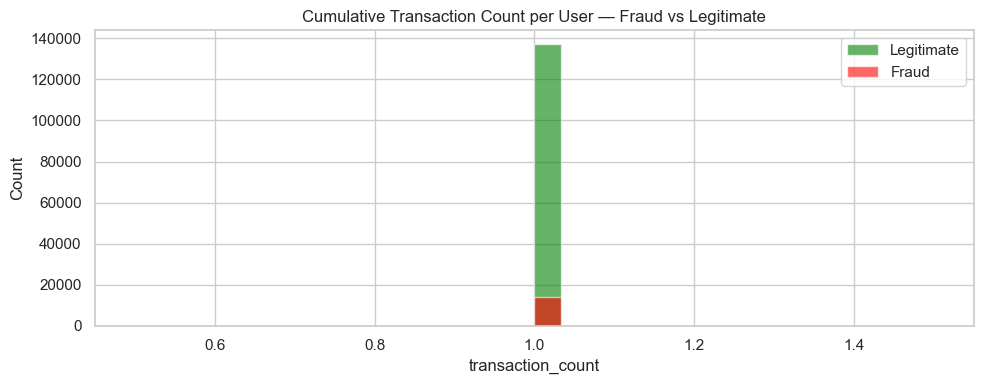

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

for label, colour, name in [(0, 'green', 'Legitimate'), (1, 'red', 'Fraud')]:
    vals = df[df['class'] == label]['transaction_count']
    ax.hist(vals, bins=30, alpha=0.6, color=colour, label=name)

ax.set_title('Cumulative Transaction Count per User — Fraud vs Legitimate')
ax.set_xlabel('transaction_count')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_transaction_count.png', dpi=150)
plt.show()

### 4.2 `transactions_last_24h`

**Why:** Burst fraud — a compromised account used rapidly before the victim notices — shows up as many transactions in a short window. This feature counts how many purchases the same user made in the 24 hours *before* the current transaction.

**Implementation:** For each transaction at time `t`, count rows from the same user where `t - 24h ≤ purchase_time < t`. We exclude the current transaction itself.

In [20]:
df = df.sort_values(['user_id', 'purchase_time']).reset_index(drop=True)

df['transactions_last_24h'] = (
    df.groupby('user_id', group_keys=False)
    .apply(lambda g: g['purchase_time'].apply(
        lambda t: ((g['purchase_time'] < t) &
                   (g['purchase_time'] >= t - pd.Timedelta(hours=24))).sum()
    ))
)

print('transactions_last_24h stats:')
print(df['transactions_last_24h'].describe())
print()
print('Fraud — mean last_24h:', df[df['class']==1]['transactions_last_24h'].mean().round(3))
print('Legit — mean last_24h:', df[df['class']==0]['transactions_last_24h'].mean().round(3))

transactions_last_24h stats:
count    151112.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: transactions_last_24h, dtype: float64

Fraud — mean last_24h: 0.0
Legit — mean last_24h: 0.0


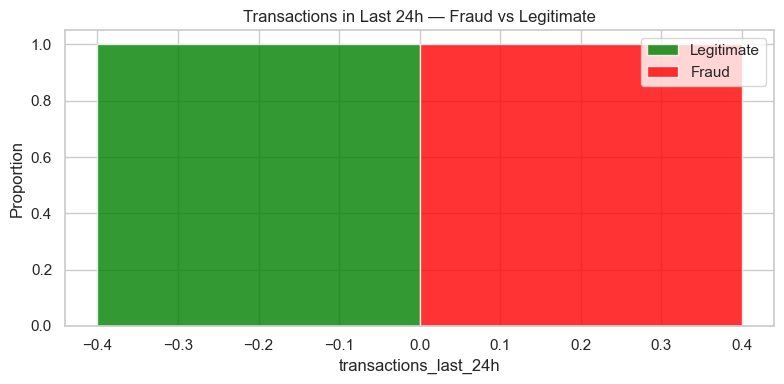

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

fraud_vals = df[df['class']==1]['transactions_last_24h'].value_counts().sort_index()
legit_vals = df[df['class']==0]['transactions_last_24h'].value_counts().sort_index()

ax.bar(legit_vals.index - 0.2, legit_vals.values / legit_vals.sum(),
       width=0.4, color='green', alpha=0.8, label='Legitimate')
ax.bar(fraud_vals.index + 0.2, fraud_vals.values / fraud_vals.sum(),
       width=0.4, color='red', alpha=0.8, label='Fraud')

ax.set_title('Transactions in Last 24h — Fraud vs Legitimate')
ax.set_xlabel('transactions_last_24h')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_transactions_last_24h.png', dpi=150)
plt.show()

## 5. Drop Columns Not Needed for Modelling

| Column | Reason for dropping |
|---|---|
| `user_id` | High-cardinality ID — model would memorise users, not patterns |
| `device_id` | Same reason |
| `ip_address` | Country already extracted |
| `signup_time` | Signal extracted into `time_since_signup` |
| `purchase_time` | Signal extracted into `hour_of_day`, `day_of_week` |

In [22]:
drop_cols = ['purchase_time', 'signup_time', 'user_id', 'device_id', 'ip_address']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print('Final columns:', list(df.columns))
print('Final shape  :', df.shape)

Final columns: ['purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'country', 'hour_of_day', 'day_of_week', 'time_since_signup', 'transaction_count', 'transactions_last_24h']
Final shape  : (151112, 12)


## 6. Final Feature Summary

In [23]:
df.describe(include='all')

,purchase_value,source,browser,sex,age,class,country,hour_of_day,day_of_week,time_since_signup,transaction_count,transactions_last_24h
count,151112.000000,151112,151112,151112,151112.000000,151112.000000,151112,151112.000000,151112.000000,1.511120e+05,151112.0,151112.0
unique,NaN,3,5,2,NaN,NaN,182,NaN,NaN,NaN,NaN,NaN
top,NaN,SEO,Chrome,M,NaN,NaN,United States,NaN,NaN,NaN,NaN,NaN
freq,NaN,60615,61432,88293,NaN,NaN,58049,NaN,NaN,NaN,NaN,NaN
mean,36.935372,NaN,NaN,NaN,33.140704,0.093646,NaN,11.521593,3.011819,4.932029e+06,1.0,0.0
std,18.322762,NaN,NaN,NaN,8.617733,0.291336,NaN,6.912474,2.006203,3.126263e+06,0.0,0.0
min,9.000000,NaN,NaN,NaN,18.000000,0.000000,NaN,0.000000,0.000000,1.000000e+00,1.0,0.0
25%,22.000000,NaN,NaN,NaN,27.000000,0.000000,NaN,6.000000,1.000000,2.186754e+06,1.0,0.0
50%,35.000000,NaN,NaN,NaN,33.000000,0.000000,NaN,12.000000,3.000000,4.926346e+06,1.0,0.0
75%,49.000000,NaN,NaN,NaN,39.000000,0.000000,NaN,17.000000,5.000000,7.644524e+06,1.0,0.0


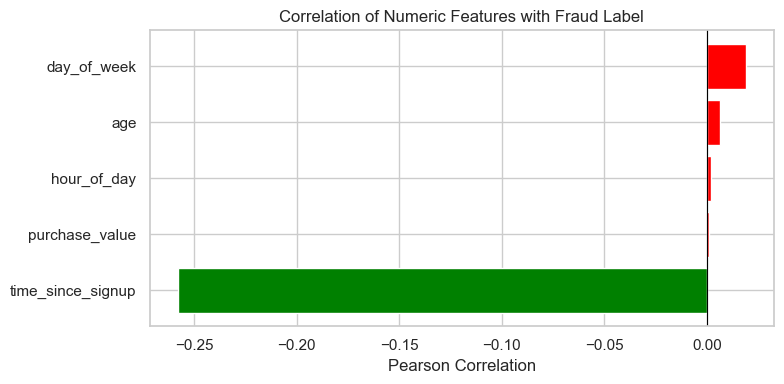

time_since_signup       -0.257888
purchase_value           0.001011
hour_of_day              0.001955
age                      0.006624
day_of_week              0.018939
transaction_count             NaN
transactions_last_24h         NaN
Name: class, dtype: float64


In [24]:
# Correlation of engineered numeric features with fraud label
num_feats = ['purchase_value', 'age', 'hour_of_day', 'day_of_week',
             'time_since_signup', 'transaction_count', 'transactions_last_24h']

corr = df[num_feats + ['class']].corr()['class'].drop('class').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['red' if v > 0 else 'green' for v in corr.values]
ax.barh(corr.index, corr.values, color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numeric Features with Fraud Label')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../notebooks/eda_plots/feat_correlation_with_class.png', dpi=150)
plt.show()

print(corr)

## 7. Save Output

In [26]:
df.to_csv('../data/processed/fraud_features1.csv', index=False)
print('Saved → data/processed/fraud_features.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Saved → data/processed/fraud_features.csv
Shape: (151112, 12)
Columns: ['purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'country', 'hour_of_day', 'day_of_week', 'time_since_signup', 'transaction_count', 'transactions_last_24h']
